In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from textblob import TextBlob
from pysentimiento import create_analyzer
import ipywidgets as widgets
from IPython.display import display, clear_output
from wordcloud import WordCloud



In [15]:
# Descargar las palabras vacías en español
nltk.download('stopwords')

# Inicializar el analizador de sentimientos en español
analyzer = create_analyzer(task="sentiment", lang="es")

# Tu base de datos con textos completos de ejemplo para cumplir con el profesor
data = {
    'Obra': ['Color Esperanza (Completa)', 'La Camisa Negra (Completa)'],
    'Texto_Completo': [
        """Sé que hay en tus ojos con solo mirar
        Que estás cansado de andar y de andar
        Y caminar girando siempre en un lugar
        Sé que las ventanas se pueden abrir
        Cambiar el aire depende de ti
        Te ayudará vale la pena una vez más
        Saber que se puede, querer que se pueda
        Quitarse los miedos, sacarlos afuera
        Pintarse la cara color esperanza
        Tentar al futuro con el corazón""",
        
        """Tengo la camisa negra
        Hoy mi amor está de luto
        Hoy tengo en el alma una pena
        Y es por culpa de tu embrujo
        Hoy sé que tú ya no me quieres
        Y eso es lo que más me hiere
        Que tengo la camisa negra
        Y una pena que me apesta"""
    ]
}

df = pd.DataFrame(data)
print("¡Datos cargados y analizador listo!")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\adanm\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

¡Datos cargados y analizador listo!


In [16]:
def limpiar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    palabras = texto.split()
    palabras_filtradas = [p for p in palabras if p not in stopwords.words('spanish')]
    return " ".join(palabras_filtradas)

# 1. Crear columna de texto limpio
df['Letra_Limpia'] = df['Texto_Completo'].apply(limpiar_texto)

# 2. Conteo de palabras (Análisis Exploratorio requerido por la rúbrica)
df['Conteo_Palabras_Original'] = df['Texto_Completo'].apply(lambda x: len(x.split()))
df['Conteo_Palabras_Limpio'] = df['Letra_Limpia'].apply(lambda x: len(x.split()))

print("Estadísticas de conteo de palabras creadas con éxito:")
df[['Obra', 'Conteo_Palabras_Original', 'Conteo_Palabras_Limpio']]

Estadísticas de conteo de palabras creadas con éxito:


,Obra,Conteo_Palabras_Original,Conteo_Palabras_Limpio
0,Color Esperanza (Completa),69,37
1,La Camisa Negra (Completa),51,18


In [17]:
# Aplicar el análisis global
df['Sentimiento'] = df['Letra_Limpia'].apply(lambda x: analyzer.predict(x).output)

# Mapear los resultados a nombres amigables
mapa = {'POS': 'Positivo', 'NEG': 'Negativo', 'NEU': 'Neutro'}
df['Sentimiento'] = df['Sentimiento'].map(mapa)

print("Análisis de sentimiento global completado:")
df[['Obra', 'Sentimiento']]

Análisis de sentimiento global completado:


,Obra,Sentimiento
0,Color Esperanza (Completa),Neutro
1,La Camisa Negra (Completa),Negativo


C:\Users\adanm\AppData\Local\Temp\ipykernel_12396\4128290821.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Sentimiento', data=df, ax=axes[0], palette='pastel', order=['Positivo', 'Neutro', 'Negativo'])
C:\Users\adanm\AppData\Local\Temp\ipykernel_12396\4128290821.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Conteo_Palabras_Limpio', y='Obra', data=df, ax=axes[1], palette='pastel')


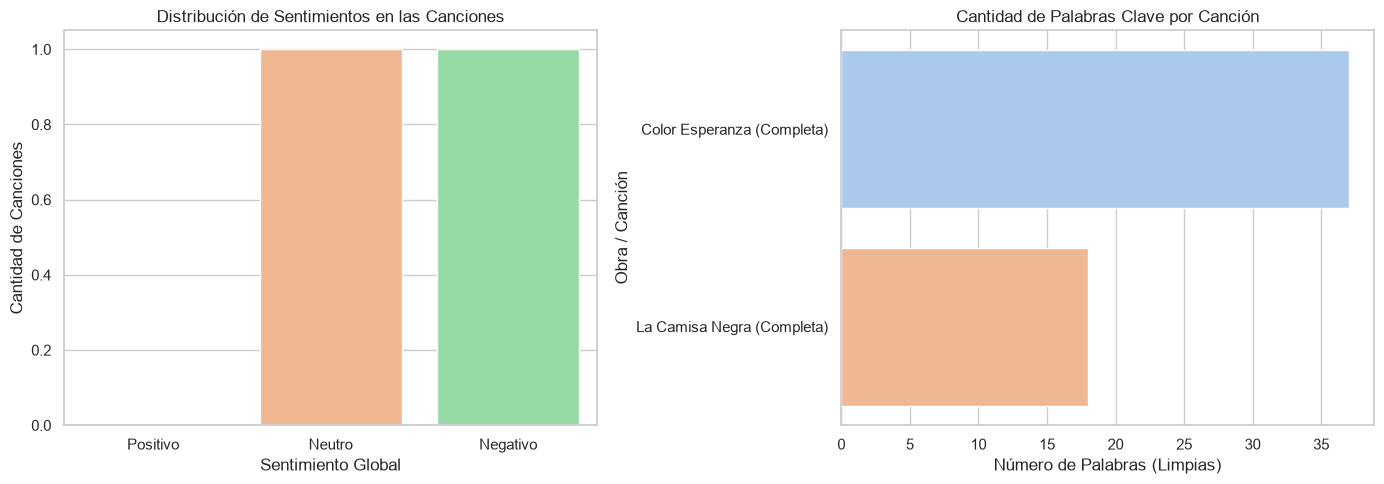

In [18]:
# Configuración de estilo de los gráficos
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Distribución de Sentimientos Globales (Usa 'Sentimiento' con S mayúscula)
sns.countplot(x='Sentimiento', data=df, ax=axes[0], palette='pastel', order=['Positivo', 'Neutro', 'Negativo'])
axes[0].set_title('Distribución de Sentimientos en las Canciones')
axes[0].set_xlabel('Sentimiento Global')
axes[0].set_ylabel('Cantidad de Canciones')

# Gráfico 2: Comparativa de Palabras por Canción (Usa 'Obra' en el eje Y)
sns.barplot(x='Conteo_Palabras_Limpio', y='Obra', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Cantidad de Palabras Clave por Canción')
axes[1].set_xlabel('Número de Palabras (Limpias)')
axes[1].set_ylabel('Obra / Canción')

plt.tight_layout()
plt.show()
    
 

In [19]:
texto_para_curva = df['Texto_Completo'][0]
nombre_obra = df['Obra'][0]

# Separar el texto por líneas individuales
lineas = [linea.strip() for linea in texto_para_curva.split('\n') if linea.strip()]

# Analizar el ritmo emocional paso a paso
historial_scores = []
for linea in lineas:
    res = analyzer.predict(linea)
    score = 1 if res.output == 'POS' else (-1 if res.output == 'NEG' else 0)
    historial_scores.append(score)

print(f"Análisis de curva completado para: {nombre_obra}")

Análisis de curva completado para: Color Esperanza (Completa)


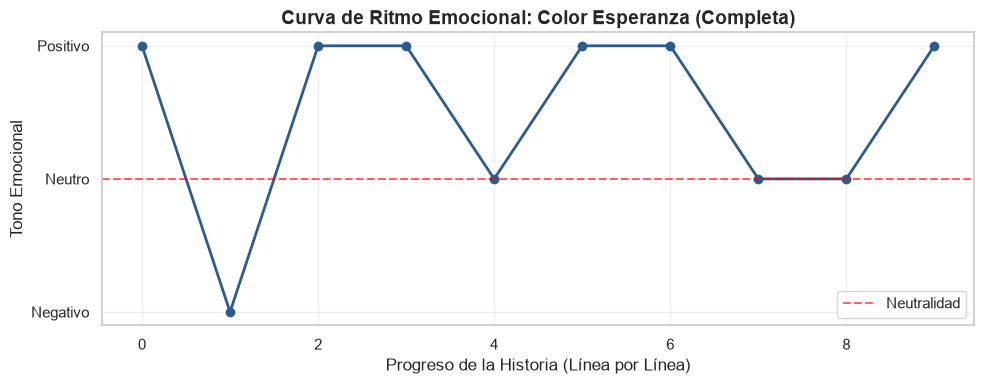

In [20]:
plt.figure(figsize=(10, 4))
plt.plot(historial_scores, marker='o', color='#2b5c8f', linestyle='-', linewidth=2, markersize=6)
plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Neutralidad')

plt.title(f'Curva de Ritmo Emocional: {nombre_obra}', fontsize=14, fontweight='bold')
plt.xlabel('Progreso de la Historia (Línea por Línea)', fontsize=12)
plt.ylabel('Tono Emocional', fontsize=12)

# Eje Y limpio para evitar los caracteres rotos [x]
plt.yticks([-1, 0, 1], ['Negativo', 'Neutro', 'Positivo'])

plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

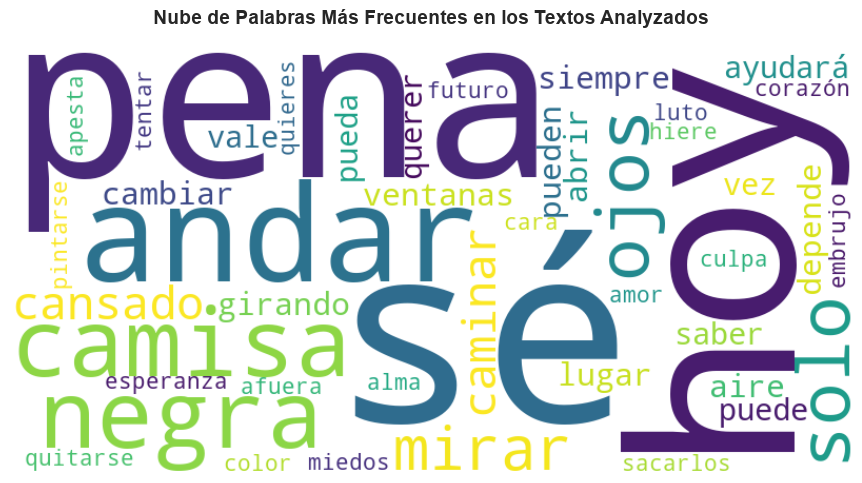

In [24]:
# 1. Unir todo el texto limpio de todas las canciones en un solo gran bloque de texto
todo_el_texto = " ".join(df['Letra_Limpia'])

# 2. Configurar y generar la Nube de Palabras
# Puedes cambiar el 'background_color' (color de fondo) o 'colormap' (paleta de colores)
wordcloud = WordCloud(
    width=800, 
    height=400, 
    background_color='white', 
    colormap='viridis', 
    max_words=100
).generate(todo_el_texto)

# 3. Graficar la nube usando Matplotlib
plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off') # Ocultamos los ejes numéricos para que solo se vea el arte de palabras
plt.title('Nube de Palabras Más Frecuentes en los Textos Analyzados', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

In [ ]:
# Componentes visuales
titulo_input = widgets.Text(placeholder='Título de tu obra...', description='Título:', layout=widgets.Layout(width='60%'))
texto_input = widgets.Textarea(placeholder='Escribe o pega tu texto aquí...', description='Texto:', layout=widgets.Layout(width='80%', height='200px'))
boton_analizar = widgets.Button(description='Analizar Escrito 🚀', button_style='success', icon='check')
zona_salida = widgets.Output()

def procesar_analisis(b):
    with zona_salida:
        clear_output(wait=True)
        titulo = titulo_input.value.strip() or "Obra sin título"
        texto = texto_input.value.strip()
        
        if not texto:
            print("❌ Por favor, ingresa algún texto.")
            return
            
        lineas_usuario = [l.strip() for l in texto.split('\n') if l.strip()]
        scores_usuario = []
        for l in lineas_usuario:
            res = analyzer.predict(l)
            scores_usuario.append(1 if res.output == 'POS' else (-1 if res.output == 'NEG' else 0))
            
        plt.figure(figsize=(10, 4))
        plt.plot(scores_usuario, marker='o', color='#1f77b4', linestyle='-', linewidth=2)
        plt.axhline(0, color='red', linestyle='--', alpha=0.6, label='Neutralidad')
        plt.title(f'Curva de Ritmo Emocional: {titulo}', fontsize=14, fontweight='bold')
        plt.xlabel('Progreso de la Historia (Línea por Línea)', fontsize=12)
        plt.ylabel('Tono Emocional', fontsize=12)
        plt.yticks([-1, 0, 1], ['Negativo', 'Neutro', 'Positivo'])
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

boton_analizar.on_click(procesar_analisis)
print("--- INTERFAZ DE USUARIO: ASISTENTE PARA ESCRITORES ---")
display(titulo_input, texto_input, boton_analizar, zona_salida)

--- INTERFAZ DE USUARIO: ASISTENTE PARA ESCRITORES ---


Text(value='', description='Título:', layout=Layout(width='60%'), placeholder='Título de tu obra...')

Textarea(value='', description='Texto:', layout=Layout(height='200px', width='80%'), placeholder='Escribe o pe…

Button(button_style='success', description='Analizar Escrito 🚀', icon='check', style=ButtonStyle())

Output()